<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_A/ML%20Exp7%20Clustering%20on%20Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Clustering on the Iris Dataset  
This notebook demonstrates **three unsupervised clustering algorithms** applied to the classic **Iris dataset**:

1. **DBSCAN (Density‑Based Spatial Clustering of Applications with Noise)**  
2. **EM – Gaussian Mixture Model (GMM)**  
3. **MST‑based Clustering (using Minimum Spanning Tree)**  

Each section is self‑contained and includes:
- Background explanation of the algorithm
- Step‑by‑step Python implementation
- Visualizations
- Evaluation metrics where applicable

> **How to use this notebook:**  
Run the cells sequentially from top to bottom. Each Markdown cell describes the purpose of the following code cell.



## 0. Install and Import Required Libraries  
The following cell installs (if needed) and imports all required Python packages.  
Run this cell first before proceeding to the algorithm sections.


In [ ]:

# Install common libraries (Colab usually has them pre‑installed)
!pip install numpy pandas matplotlib seaborn scikit-learn scipy networkx

# Import commonly used libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Silence warnings (optional)
import warnings
warnings.filterwarnings('ignore')

print("All required libraries are ready.")


All required libraries are ready.



# 1. DBSCAN Clustering on the Iris Dataset  

### Background  
DBSCAN is a density‑based clustering algorithm that groups points that are closely packed together and labels sparse points as noise or outliers.  

### Steps in this section:  
1. Load the Iris dataset from a CSV file.  
2. Pre‑process the data (drop non‑numeric columns, scale features).  
3. Apply **DBSCAN** clustering with user‑provided `epsilon` and `min_samples`.  
4. Visualize the resulting clusters and outliers in 2‑D using PCA.  
5. Compute validation metrics such as Silhouette Score, Adjusted Rand Index, Homogeneity, and Completeness scores.  

> **Instruction:** Run each cell in order and adjust `epsilon` and `min_samples` to experiment with different cluster densities.


In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()

# Convert it into a pandas DataFrame for easy handling
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['target'] = iris.target

print("Dataset loaded successfully using sklearn!")
print(data.head())

Dataset loaded successfully using sklearn!
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [ ]:
# Step 2: Pre-process the data for clustering
from sklearn.preprocessing import StandardScaler

# If the DataFrame contains an ID column, drop it
if 'Id' in data.columns:
    print("Dropping ID column...")
    data = data.drop('Id', axis=1)

# Drop the target column (true labels) to perform unsupervised clustering
if 'target' in data.columns:
    print("Dropping target column for clustering...")
    data = data.drop('target', axis=1)

# If there is a species column (string labels), drop it as well
if 'species' in data.columns:
    print("Dropping species column for clustering...")
    data = data.drop('species', axis=1)

# Scale the features for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

print("✅ Data preprocessing completed.")
print(f"Columns used for clustering: {list(data.columns)}")


Dropping target column for clustering...
✅ Data preprocessing completed.
Columns used for clustering: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:

# Step 3: Apply DBSCAN clustering
from sklearn.cluster import DBSCAN

# Prompt user for parameters
eps = float(input("Enter epsilon (for example, 0.6): "))
min_samples = int(input("Enter minimum samples (for example, 5): "))

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

# Store cluster labels in a new DataFrame for inspection
df_clustered = pd.DataFrame(X_scaled, columns=data.columns)
df_clustered['Cluster'] = labels

print("DBSCAN clustering completed.")
print(df_clustered.head())


Enter epsilon (for example, 0.6): 0.45
Enter minimum samples (for example, 5): 5
DBSCAN clustering completed.
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   
3          -1.506521          0.098217          -1.283389         -1.315444   
4          -1.021849          1.249201          -1.340227         -1.315444   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


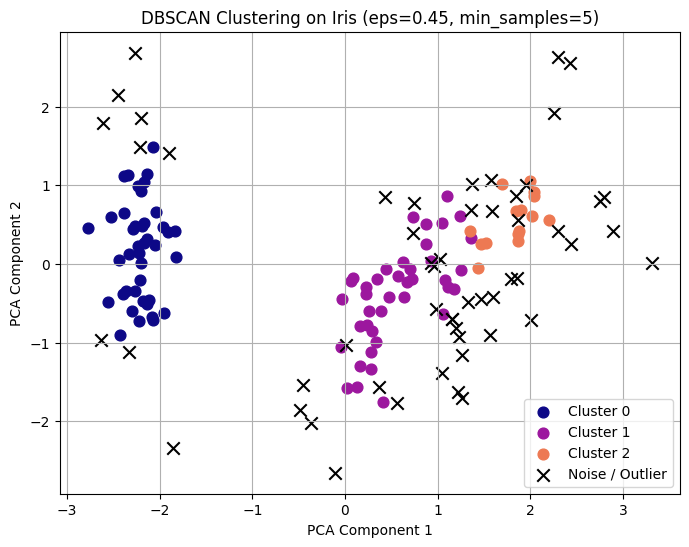

In [ ]:

# Step 4: Visualize clusters and outliers in 2‑D using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

unique_labels = set(labels)
colors = plt.cm.plasma(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(8,6))

for label, color in zip(unique_labels, colors):
    if label == -1:
        plt.scatter(X_pca[labels == label, 0],
                    X_pca[labels == label, 1],
                    c='black', marker='x', s=80, label='Noise / Outlier')
    else:
        plt.scatter(X_pca[labels == label, 0],
                    X_pca[labels == label, 1],
                    c=[color], s=60, label=f'Cluster {label}')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"DBSCAN Clustering on Iris (eps={eps}, min_samples={min_samples})")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Step 5: Compute clustering metrics for DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_score, completeness_score, davies_bouldin_score
import numpy as np

# Number of clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters (excluding noise): {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Use true labels from sklearn's Iris dataset
y_true = iris.target    # already loaded in Step 1

# Compute metrics only if there’s at least 2 clusters (excluding noise)
if n_clusters > 0 and len(set(labels)) > 1:
    silhouette = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
    ari = adjusted_rand_score(y_true, labels)
    homogeneity = homogeneity_score(y_true, labels)
    completeness = completeness_score(y_true, labels)
    dbi = davies_bouldin_score(X_scaled[labels != -1], labels[labels != -1])

    print("Silhouette Score:", round(silhouette, 3))
    print("Adjusted Rand Index:", round(ari, 3))
    print("Homogeneity Score:", round(homogeneity, 3))
    print("Completeness Score:", round(completeness, 3))
    print("Davies Bouldin Score:", round(dbi, 3))
else:
    print("Too few clusters to compute metrics – adjust eps and min_samples.")


Number of clusters (excluding noise): 3
Number of noise points: 54
Silhouette Score: 0.545
Adjusted Rand Index: 0.517
Homogeneity Score: 0.646
Completeness Score: 0.544
Davies Bouldin Score: 0.659



# 2. EM Clustering (Gaussian Mixture Model) on the Iris Dataset  

### Background  
The **Expectation–Maximization (EM)** algorithm implemented via **Gaussian Mixture Models (GMM)** assumes that the data is generated from a mixture of Gaussian distributions.  
It alternates between assigning points to clusters (E‑step) and updating the cluster parameters (M‑step) until convergence.

### Steps in this section:  
1. Load the Iris dataset directly from `sklearn.datasets`.  
2. Use only the first two features to make 2‑D visualization easier.  
3. Fit a GMM model with 3 components (since the Iris dataset has 3 species).  
4. Compute evaluation metrics such as Log‑Likelihood, AIC, BIC, Silhouette Score, and Davies–Bouldin Index.  
5. Visualize the clusters with their centers.  

> **Instruction:** Provide a convergence threshold (epsilon) when prompted to control the stopping criterion for the EM algorithm.


Enter convergence threshold (epsilon, e.g., 1e-3): 1e-3
Shape of X: (150, 2)
Shape of true labels: (150,)
Converged: True
Iterations: 8
Log‑likelihood: -1.5
AIC: 483.4 BIC: 534.58
Silhouette Score: 0.44
Davies–Bouldin Index: 0.77


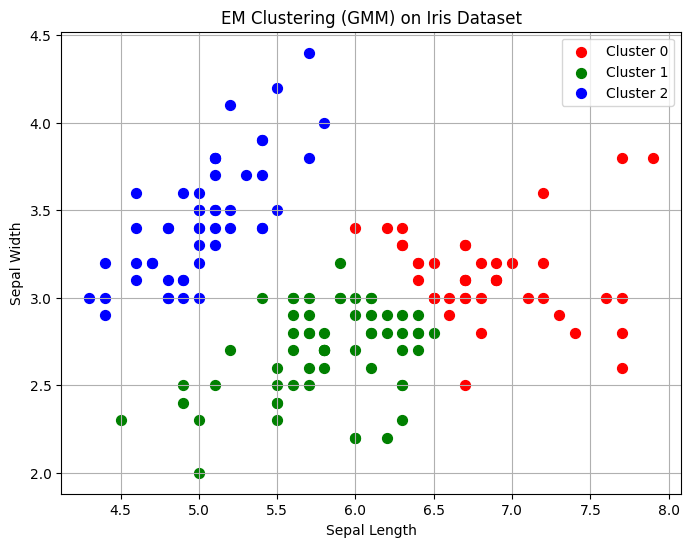

In [ ]:

from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Step 1: User input for convergence threshold
epsilon = float(input("Enter convergence threshold (epsilon, e.g., 1e-3): "))

# Step 2: Load Iris dataset (using first two features for easy visualization)
iris = load_iris()
X = iris.data[:, :2]    # first two features
y_true = iris.target

print("Shape of X:", X.shape)
print("Shape of true labels:", y_true.shape)

# Step 3: Fit Gaussian Mixture Model
n_clusters = 3
gmm = GaussianMixture(n_components=n_clusters, tol=epsilon, random_state=42, max_iter=300)
gmm.fit(X)

# Step 4: Predict cluster labels
y_pred = gmm.predict(X)

# Step 5: Evaluate clustering quality
log_likelihood = gmm.lower_bound_
aic = gmm.aic(X)
bic = gmm.bic(X)
silhouette = silhouette_score(X, y_pred)
dbi = davies_bouldin_score(X, y_pred)

print("Converged:", gmm.converged_)
print("Iterations:", gmm.n_iter_)
print("Log‑likelihood:", round(log_likelihood, 2))
print("AIC:", round(aic, 2), "BIC:", round(bic, 2))
print("Silhouette Score:", round(silhouette, 2))
print("Davies–Bouldin Index:", round(dbi, 2))

# Step 6: Visualization of clusters and their centers
plt.figure(figsize=(8,6))
colors = ['red', 'green', 'blue']

for i in range(n_clusters):
    cluster_points = X[y_pred == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                s=50, color=colors[i], label=f'Cluster {i}')



plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("EM Clustering (GMM) on Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()



# 3. MST‑based Clustering on the Iris Dataset  

### Background  
MST‑based clustering creates a **Minimum Spanning Tree** of all data points based on pairwise distances.  
By **cutting the k‑1 longest edges** of the MST, the graph breaks into *k* connected components, each representing a cluster.

### Steps in this section:  
1. Load and standardize the Iris dataset.  
2. Build a complete graph using Manhattan distance.  
3. Construct the MST using Kruskal’s algorithm (via NetworkX).  
4. Remove the longest edges to form a fixed number of clusters.  
5. Evaluate clustering using Silhouette Score, Davies–Bouldin Index, and Dunn Index.  
6. Visualize clusters in 2‑D space using PCA with the MST edges overlaid.  

> **Instruction:** Adjust `k_clusters` in the code cell to select how many clusters to form by cutting the MST edges.


Iris dataset loaded and standardized. (150, 4)
Complete graph built with 150 nodes.
MST computed with 149 edges.
Clusters formed: [50, 98, 2]
Removed longest edges: [(41, 93, 2.664), (109, 117, 1.802)]
MST clustering metrics: {'Silhouette': np.float64(0.49486290250095627), 'Davies_Bouldin': np.float64(0.5344024833668791), 'Dunn': np.float64(0.17837486350971013), 'Adjusted_Rand': 0.5637510205230709}


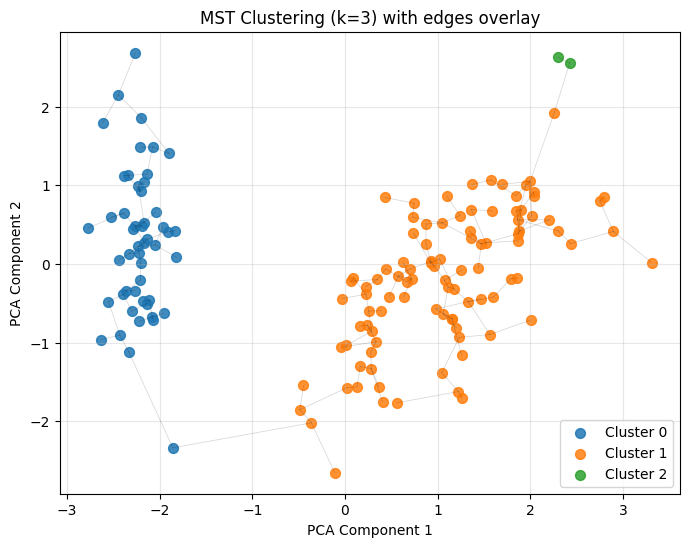

In [ ]:

import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from scipy.spatial.distance import pdist, squareform

# Dunn Index implementation
def dunn_index(X, labels):
    unique_labels = [lab for lab in np.unique(labels) if lab != -1]
    if len(unique_labels) < 2:
        return np.nan

    dist = squareform(pdist(X, metric='euclidean'))
    diameters = []
    for lab in unique_labels:
        idx = np.where(labels == lab)[0]
        diameters.append(np.max(dist[np.ix_(idx, idx)]) if len(idx) > 1 else 0.0)
    max_diameter = max(diameters) if diameters else 1e-12

    inter_dists = []
    for i, li in enumerate(unique_labels):
        for lj in unique_labels[i+1:]:
            idx_i = np.where(labels == li)[0]
            idx_j = np.where(labels == lj)[0]
            inter_dists.append(np.min(dist[np.ix_(idx_i, idx_j)]))
    if not inter_dists:
        return np.nan
    return min(inter_dists) / max_diameter

# Load Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Iris dataset loaded and standardized.", X_scaled.shape)

# Build complete graph with Manhattan distance
dist_matrix = squareform(pdist(X_scaled, metric='cityblock'))
G = nx.Graph()
n = X_scaled.shape[0]
G.add_nodes_from(range(n))
for i in range(n):
    for j in range(i+1, n):
        G.add_edge(i, j, weight=float(dist_matrix[i, j]))

print("Complete graph built with", G.number_of_nodes(), "nodes.")

# Compute MST
mst = nx.minimum_spanning_tree(G, weight='weight')
print("MST computed with", mst.number_of_edges(), "edges.")

# Function to cut MST edges and form clusters
def mst_clustering(mst_graph, k_clusters):
    T = mst_graph.copy()
    sorted_edges = sorted(T.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
    removed = sorted_edges[:k_clusters-1]
    T.remove_edges_from([(u, v) for u, v, w in removed])

    comps = list(nx.connected_components(T))
    labels = np.full(n, -1, dtype=int)
    for cid, comp in enumerate(comps):
        for node in comp:
            labels[node] = cid
    return labels, removed, comps

# Choose number of clusters
k = 3
labels_mst, removed_edges, comps = mst_clustering(mst, k)

print("Clusters formed:", [len(c) for c in comps])
print("Removed longest edges:", [(u, v, round(d['weight'],3)) for u, v, d in removed_edges])

# Evaluate performance
def compute_metrics(X, labels, y_true):
    metrics = {}
    if len(set(labels)) > 1:
        metrics['Silhouette'] = silhouette_score(X, labels)
        metrics['Davies_Bouldin'] = davies_bouldin_score(X, labels)
        metrics['Dunn'] = dunn_index(X, labels)
        metrics['Adjusted_Rand'] = adjusted_rand_score(y_true, labels)
    else:
        metrics['Silhouette'] = metrics['Davies_Bouldin'] = metrics['Dunn'] = np.nan
        metrics['Adjusted_Rand'] = np.nan
    return metrics

metrics_mst = compute_metrics(X_scaled, labels_mst, iris.target)
print("MST clustering metrics:", metrics_mst)

# Visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

def plot_mst_clusters(X2d, labels, mst_graph, title="MST Clustering"):
    plt.figure(figsize=(8,6))
    unique = sorted(np.unique(labels))
    palette = sns.color_palette("tab10", n_colors=len(unique))
    color_map = {lab: palette[i] for i, lab in enumerate(unique)}

    for lab in unique:
        mask = labels == lab
        plt.scatter(X2d[mask,0], X2d[mask,1],
                    c=[color_map[lab]], s=50, label=f'Cluster {lab}', alpha=0.85)

    pos_map = {i: X2d[i] for i in range(X2d.shape[0])}
    for u, v, d in mst_graph.edges(data=True):
        plt.plot([pos_map[u][0], pos_map[v][0]], [pos_map[u][1], pos_map[v][1]],
                 color='black', alpha=0.15, linewidth=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_mst_clusters(X_pca, labels_mst, mst, title=f"MST Clustering (k={k}) with edges overlay")



# 4. Summary  
We have successfully implemented and compared **three unsupervised clustering methods** on the Iris dataset:

- **DBSCAN** clusters based on point density and identifies outliers.  
- **EM (GMM)** models each cluster as a Gaussian distribution.  
- **MST‑based clustering** partitions data by cutting the longest edges of a Minimum Spanning Tree.  

Each algorithm has different assumptions and is useful for different kinds of data distributions.  

You can modify parameters (`eps`, `min_samples`, `epsilon`, `k`) to explore how clustering results change.
